# Seeing Clearly: Final Reproducibility Notebook

This notebook is our reproducibility record for the final Seeing Clearly project. It loads the FER-2013 dataset, trains or selects our ResNet-18 facial-expression model, evaluates it on a held-out test set, and regenerates the figures we use in the blog post.

Our main question is not just whether the classifier can get a high accuracy score. Because our prototype is framed as an assistive webcam tool, we also care about when the model is reliable enough to show a cue, when it should be treated as uncertain, and which expression categories remain fragile.

A note on language: throughout the notebook we use FER-2013's class names because they are the dataset labels. We do not mean that a facial expression is direct proof of someone's internal emotional state.

## ML Formulation

We formulate the task as supervised image classification.

- **Input `x`:** a cropped face image from FER-2013, or a face crop extracted from a webcam frame in the prototype.
- **Output `y`:** one of the seven FER-2013 expression labels: angry, disgust, fear, happy, neutral, sad, or surprise.
- **Model:** a ResNet-18 backbone with a dropout-regularized classification head.
- **Training objective:** cross-entropy loss over the seven classes.
- **Evaluation metrics:** overall accuracy, per-class accuracy, normalized confusion matrix, confidence-threshold coverage/accuracy, and a calibration-style reliability diagram.

These metrics are meant to answer two questions at once: how well the classifier performs as a model, and how cautious a live interface should be when presenting its predictions to a user.

In [15]:
%pip install torch torchvision numpy>=2.1 matplotlib>=3.9 scikit-learn>=1.5 kagglehub>=0.3.12 jupyter>=1.1 notebook>=7.2

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURE_DIR = PROJECT_ROOT / "assets" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = PROJECT_ROOT / "models" / "fer_best_model.pth"
METADATA_PATH = PROJECT_ROOT / "models" / "fer_best_model.json"

print(PROJECT_ROOT)
print(FIGURE_DIR)


/content
/content/assets/figures


In [16]:
import copy
import json
import random
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def create_resnet18(num_classes=7, pretrained=False):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes),
    )
    return model


def build_dataset_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])


def build_training_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.72, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(18),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.12), shear=6),
        transforms.ColorJitter(brightness=0.18, contrast=0.24),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.0), value=0),
        transforms.Normalize(mean=MEAN, std=STD),
    ])


def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint
    return {
        "architecture": "resnet18",
        "class_names": CLASS_NAMES,
        "state_dict": checkpoint,
    }


def build_model(path, device):
    checkpoint = load_checkpoint(path, device)
    class_names = checkpoint.get("class_names", CLASS_NAMES)
    architecture = checkpoint.get("architecture", "resnet18")
    if architecture != "resnet18":
        raise ValueError(f"This final notebook expects a ResNet-18 checkpoint, got {architecture!r}.")
    model = create_resnet18(num_classes=len(class_names), pretrained=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint


def unnormalize_image(image_tensor):
    image = image_tensor.detach().cpu().clone().numpy().transpose(1, 2, 0)
    image = image * np.array(STD) + np.array(MEAN)
    return np.clip(image, 0, 1)


device = get_device()
if device.type == "cuda":
    print("Using CUDA GPU:", torch.cuda.get_device_name(0), flush=True)
elif device.type == "mps":
    print("Using Apple Silicon MPS", flush=True)
else:
    print("Using CPU. Note: Colab TPU runtimes require torch_xla and are not supported by this notebook; use a Colab GPU runtime for acceleration.", flush=True)
device


Using CUDA GPU: NVIDIA A100-SXM4-40GB


device(type='cuda')

## Load Dataset

This cell loads FER-2013. By default, it uses `kagglehub` to download the dataset. If you already have the dataset locally, set `DATASET_ROOT` to the directory containing `train/` and `test/`.

The final figures in our blog post are generated from the FER-2013 test split, while model selection is done using a validation split created from the training data.

In [17]:
DATASET_ROOT = None


def find_cached_fer2013():
    candidates = [
        Path.home() / ".cache" / "kagglehub" / "datasets" / "msambare" / "fer2013" / "versions" / "1",
    ]
    for candidate in candidates:
        if (candidate / "train").exists() and (candidate / "test").exists():
            return candidate
    return None


if DATASET_ROOT is not None:
    dataset_root = Path(DATASET_ROOT).expanduser().resolve()
else:
    cached_root = find_cached_fer2013()
    dataset_root = cached_root if cached_root is not None else Path(kagglehub.dataset_download("msambare/fer2013")).resolve()

train_dir = dataset_root / "train"
test_dir = dataset_root / "test"
assert train_dir.exists(), train_dir
assert test_dir.exists(), test_dir

train_dataset = ImageFolder(train_dir, transform=build_dataset_transform())
test_dataset = ImageFolder(test_dir, transform=build_dataset_transform())
class_names = train_dataset.classes or CLASS_NAMES

len(train_dataset), len(test_dataset), class_names, dataset_root


Using Colab cache for faster access to the 'fer2013' dataset.


(28709,
 7178,
 ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
 PosixPath('/kaggle/input/fer2013'))

## Figure 1: FER-2013 Examples

We start by visualizing one example from each class. This figure is useful because it makes the difficulty of the problem visible: FER-2013 images are small, grayscale, and sometimes ambiguous even to a human viewer. That ambiguity is part of why we treat the model's output as a cue rather than a definitive reading of emotion.

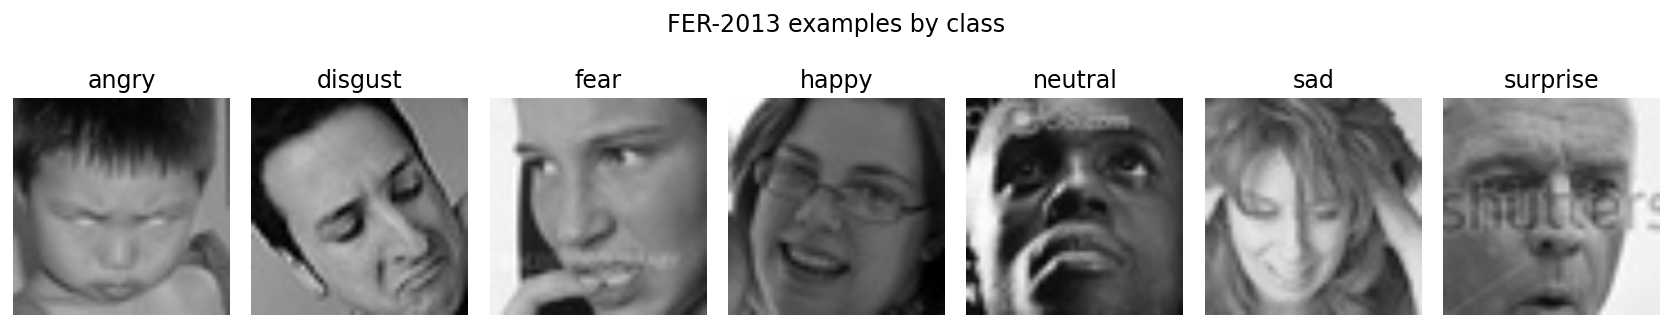

In [18]:
def first_example_per_class(dataset):
    selected = {}
    for idx, (_, label) in enumerate(dataset.samples):
        if label not in selected:
            selected[label] = idx
        if len(selected) == len(dataset.classes):
            break
    return [selected[i] for i in range(len(dataset.classes))]

example_indices = first_example_per_class(train_dataset)
fig, axes = plt.subplots(1, len(example_indices), figsize=(13, 2.4))
for ax, idx in zip(axes, example_indices):
    image_tensor, label = train_dataset[idx]
    ax.imshow(unnormalize_image(image_tensor), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
fig.suptitle("FER-2013 examples by class", y=1.05)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fer2013_examples.png", bbox_inches="tight")
plt.show()

## Optional Earlier Refit Experiment

This block records one of our earlier attempts to improve the model after the first prototype. The original checkpoint was much weaker on `angry`, `fear`, and `sad` than on easier classes such as `happy` and `surprise`, so we tried class-balanced sampling, class-weighted loss, stronger augmentation, and model selection based partly on weak-class validation accuracy.

We keep this block in the notebook because it documents what we tried. For the final model claim, however, we use the cleaner protocol below. Leave `RUN_TRAINING = False` unless you intentionally want to reproduce this earlier refit.

In [19]:
RUN_TRAINING = False
ALLOW_RANDOM_INIT = False
WEAK_CLASS_NAMES = {"angry", "fear", "sad"}
WEAK_CLASS_BOOST = 1.4


def subset_targets(subset):
    return np.array([subset.dataset.targets[i] for i in subset.indices], dtype=int)


def make_balanced_sampler(train_dataset, class_names):
    targets = subset_targets(train_dataset)
    counts = np.bincount(targets, minlength=len(class_names))
    class_weights = 1.0 / np.maximum(counts, 1)
    for idx, name in enumerate(class_names):
        if name in WEAK_CLASS_NAMES:
            class_weights[idx] *= WEAK_CLASS_BOOST
    sample_weights = class_weights[targets]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    # Use the square root for the loss so sampling and loss weighting do not overcorrect too aggressively.
    loss_weights = np.sqrt(class_weights / class_weights.mean())
    return sampler, torch.as_tensor(loss_weights, dtype=torch.float32), counts


def evaluate_loader(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0.0
    total_seen = 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_seen += labels.size(0)
            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    per_class = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    weak_indices = [i for i, name in enumerate(class_names) if name in WEAK_CLASS_NAMES]
    return {
        "loss": total_loss / total_seen,
        "acc": float((y_true == y_pred).mean()),
        "macro_acc": float(per_class.mean()),
        "weak_acc": float(per_class[weak_indices].mean()),
        "per_class_acc": per_class,
    }


def train_balanced_resnet18(train_dir, output_path, base_checkpoint_path=MODEL_PATH, epochs=14, batch_size=32, learning_rate=2e-4, val_fraction=0.15, log_every=25):
    """Optional refit path aimed at improving angry/fear/sad performance.

    This fine-tunes from our existing FER checkpoint instead of downloading
    ImageNet weights, which keeps the notebook runnable offline.
    """
    full_train_aug = ImageFolder(train_dir, transform=build_training_transform())
    full_train_eval = ImageFolder(train_dir, transform=build_dataset_transform())
    val_size = int(len(full_train_aug) * val_fraction)
    train_size = len(full_train_aug) - val_size
    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(full_train_aug, [train_size, val_size], generator=generator)
    val_dataset.dataset = full_train_eval

    sampler, loss_weights, counts = make_balanced_sampler(train_dataset, full_train_aug.classes)
    print("training counts:", dict(zip(full_train_aug.classes, counts.tolist())), flush=True)
    print("loss weights:", dict(zip(full_train_aug.classes, np.round(loss_weights.numpy(), 3))), flush=True)

    num_workers = 2 if device.type == "cuda" else 0
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    print(f"device={device} | epochs={epochs} | batch_size={batch_size} | train_batches={len(train_loader)} | val_batches={len(val_loader)}", flush=True)

    model = create_resnet18(num_classes=len(full_train_aug.classes), pretrained=False).to(device)
    base_checkpoint_path = Path(base_checkpoint_path) if base_checkpoint_path is not None else None
    if base_checkpoint_path is not None and base_checkpoint_path.exists():
        base_checkpoint = load_checkpoint(base_checkpoint_path, device)
        model.load_state_dict(base_checkpoint["state_dict"])
        print("initialized from existing FER checkpoint:", base_checkpoint_path, flush=True)
    elif ALLOW_RANDOM_INIT:
        print("WARNING: training from random initialization because ALLOW_RANDOM_INIT=True", flush=True)
    else:
        raise FileNotFoundError(
            f"Base checkpoint not found at {base_checkpoint_path}. "
            "Upload models/fer_best_model.pth to Colab or set ALLOW_RANDOM_INIT=True intentionally."
        )

    criterion = nn.CrossEntropyLoss(weight=loss_weights.to(device), label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_state = None
    best_score = -1.0
    best_epoch = 0
    history = []

    total_start = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        print(f"\nEpoch {epoch}/{epochs} started", flush=True)
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_seen = 0
        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * labels.size(0)
            train_correct += int((logits.argmax(dim=1) == labels).sum().item())
            train_seen += labels.size(0)

            if batch_idx == 1 or batch_idx % log_every == 0 or batch_idx == len(train_loader):
                running_loss = train_loss / train_seen
                running_acc = train_correct / train_seen
                elapsed = time.time() - epoch_start
                print(
                    f"  batch {batch_idx:04d}/{len(train_loader):04d} | "
                    f"loss={running_loss:.4f} | acc={running_acc:.3f} | elapsed={elapsed/60:.1f}m",
                    flush=True,
                )
        scheduler.step()

        print("  validating...", flush=True)
        val_metrics = evaluate_loader(model, val_loader, criterion, len(full_train_aug.classes))
        score = 0.5 * val_metrics["macro_acc"] + 0.5 * val_metrics["weak_acc"]
        row = {
            "epoch": epoch,
            "train_loss": train_loss / train_seen,
            "train_acc": train_correct / train_seen,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_acc": val_metrics["macro_acc"],
            "val_weak_acc": val_metrics["weak_acc"],
            "selection_score": score,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        epoch_elapsed = time.time() - epoch_start
        total_elapsed = time.time() - total_start
        print(
            f"Epoch {epoch}/{epochs} done in {epoch_elapsed/60:.1f}m | "
            f"train_acc={row['train_acc']:.3f} | val_acc={row['val_acc']:.3f} | "
            f"macro={row['val_macro_acc']:.3f} | weak={row['val_weak_acc']:.3f} | "
            f"score={row['selection_score']:.3f} | total={total_elapsed/60:.1f}m",
            flush=True,
        )
        print("  per-class:", dict(zip(full_train_aug.classes, np.round(val_metrics["per_class_acc"], 3))), flush=True)

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            output_path = Path(output_path)
            output_path.parent.mkdir(parents=True, exist_ok=True)
            emergency_checkpoint = {
                "architecture": "resnet18",
                "class_names": full_train_aug.classes,
                "state_dict": best_state,
                "best_epoch": best_epoch,
                "selection_metric": "0.5 * val_macro_acc + 0.5 * val_weak_acc",
                "selection_score": best_score,
                "dataset": "FER2013",
                "weak_classes": sorted(WEAK_CLASS_NAMES),
                "weak_class_boost": WEAK_CLASS_BOOST,
                "history": history,
            }
            torch.save(emergency_checkpoint, output_path)
            print("  saved new best checkpoint to", output_path, flush=True)

    checkpoint = {
        "architecture": "resnet18",
        "class_names": full_train_aug.classes,
        "state_dict": best_state,
        "best_epoch": best_epoch,
        "selection_metric": "0.5 * val_macro_acc + 0.5 * val_weak_acc",
        "selection_score": best_score,
        "dataset": "FER2013",
        "weak_classes": sorted(WEAK_CLASS_NAMES),
        "weak_class_boost": WEAK_CLASS_BOOST,
        "history": history,
    }
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, output_path)
    print("Saved checkpoint to", output_path, flush=True)
    return checkpoint


if RUN_TRAINING:
    trained_checkpoint = train_balanced_resnet18(train_dir, MODEL_PATH)
    METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    METADATA_PATH.write_text(json.dumps({k: v for k, v in trained_checkpoint.items() if k != "state_dict"}, indent=2))
    print("Saved refit checkpoint to", MODEL_PATH, flush=True)
else:
    print("Skipping training and using the saved checkpoint. Set RUN_TRAINING=True to run the balanced refit experiment.", flush=True)


Skipping training and using the saved checkpoint. Set RUN_TRAINING=True to run the balanced refit experiment.


## Exploratory Continuation Sweep

This block is exploratory. It continues training from an already FER-trained checkpoint and tests a few plausible hyperparameter changes: lower learning rate, weak-class weighting, and label smoothing.

The sweep was useful for guiding our thinking, but it should not be used as the final evidence because the continuation setup can make validation comparisons hard to interpret. We leave `RUN_REFINEMENT_SWEEP = False` for normal reproduction.

In [20]:
RUN_REFINEMENT_SWEEP = False

REFINEMENT_CONFIGS = [
    {
        "name": "low_lr_continuation_boost_1_2",
        "epochs": 6,
        "learning_rate": 5e-5,
        "weight_decay": 2e-4,
        "weak_class_boost": 1.2,
        "label_smoothing": 0.05,
        "score_weights": {"val": 0.4, "macro": 0.4, "weak": 0.2},
    },
    {
        "name": "low_lr_continuation_boost_1_4",
        "epochs": 6,
        "learning_rate": 5e-5,
        "weight_decay": 2e-4,
        "weak_class_boost": 1.4,
        "label_smoothing": 0.05,
        "score_weights": {"val": 0.4, "macro": 0.4, "weak": 0.2},
    },
    {
        "name": "less_smoothing_boost_1_4",
        "epochs": 6,
        "learning_rate": 5e-5,
        "weight_decay": 2e-4,
        "weak_class_boost": 1.4,
        "label_smoothing": 0.03,
        "score_weights": {"val": 0.4, "macro": 0.4, "weak": 0.2},
    },
]


def make_stratified_indices(targets, val_fraction=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    targets = np.asarray(targets)
    train_indices = []
    val_indices = []
    for class_idx in np.unique(targets):
        class_indices = np.flatnonzero(targets == class_idx)
        rng.shuffle(class_indices)
        val_count = max(1, int(round(len(class_indices) * val_fraction)))
        val_indices.extend(class_indices[:val_count].tolist())
        train_indices.extend(class_indices[val_count:].tolist())
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return train_indices, val_indices


class IndexedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        return self.dataset[self.indices[index]]


def make_refinement_sampler(train_indices, targets, class_names, weak_class_boost):
    subset_y = np.asarray(targets)[train_indices]
    counts = np.bincount(subset_y, minlength=len(class_names))
    class_weights = 1.0 / np.maximum(counts, 1)
    for idx, name in enumerate(class_names):
        if name in WEAK_CLASS_NAMES:
            class_weights[idx] *= weak_class_boost
    sample_weights = class_weights[subset_y]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    loss_weights = np.sqrt(class_weights / class_weights.mean())
    return sampler, torch.as_tensor(loss_weights, dtype=torch.float32), counts


def refinement_score(metrics, score_weights):
    return (
        score_weights["val"] * metrics["acc"]
        + score_weights["macro"] * metrics["macro_acc"]
        + score_weights["weak"] * metrics["weak_acc"]
    )


def train_refinement_experiment(config, train_dir, base_checkpoint_path=MODEL_PATH):
    print(f"\n=== Refinement experiment: {config['name']} ===", flush=True)
    train_aug = ImageFolder(train_dir, transform=build_training_transform())
    train_eval = ImageFolder(train_dir, transform=build_dataset_transform())
    train_indices, val_indices = make_stratified_indices(train_aug.targets, val_fraction=0.15, seed=SEED)
    train_dataset = IndexedDataset(train_aug, train_indices)
    val_dataset = IndexedDataset(train_eval, val_indices)

    sampler, loss_weights, counts = make_refinement_sampler(
        train_indices,
        train_aug.targets,
        train_aug.classes,
        weak_class_boost=config["weak_class_boost"],
    )
    print("training counts:", dict(zip(train_aug.classes, counts.tolist())), flush=True)
    print("loss weights:", dict(zip(train_aug.classes, np.round(loss_weights.numpy(), 3))), flush=True)

    num_workers = 2 if device.type == "cuda" else 0
    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)

    model = create_resnet18(num_classes=len(train_aug.classes), pretrained=False).to(device)
    base_checkpoint = load_checkpoint(base_checkpoint_path, device)
    model.load_state_dict(base_checkpoint["state_dict"])
    print("initialized from:", base_checkpoint_path, flush=True)

    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if name.startswith("fc."):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": config["learning_rate"]},
            {"params": head_params, "lr": config["learning_rate"] * 4},
        ],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["epochs"],
        eta_min=1e-6,
    )
    criterion = nn.CrossEntropyLoss(
        weight=loss_weights.to(device),
        label_smoothing=config["label_smoothing"],
    )

    best_state = None
    best_score = -1.0
    best_epoch = 0
    history = []

    for epoch in range(1, config["epochs"] + 1):
        start = time.time()
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_seen = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * labels.size(0)
            train_correct += int((logits.argmax(dim=1) == labels).sum().item())
            train_seen += labels.size(0)
        scheduler.step()

        metrics = evaluate_loader(model, val_loader, criterion, len(train_aug.classes))
        score = refinement_score(metrics, config["score_weights"])
        row = {
            "experiment": config["name"],
            "epoch": epoch,
            "train_loss": train_loss / train_seen,
            "train_acc": train_correct / train_seen,
            "val_loss": metrics["loss"],
            "val_acc": metrics["acc"],
            "val_macro_acc": metrics["macro_acc"],
            "val_weak_acc": metrics["weak_acc"],
            "selection_score": score,
            "lr_backbone": optimizer.param_groups[0]["lr"],
            "lr_head": optimizer.param_groups[1]["lr"],
        }
        history.append(row)
        print(
            f"epoch {epoch}/{config['epochs']} | "
            f"train={row['train_acc']:.3f} val={row['val_acc']:.3f} "
            f"macro={row['val_macro_acc']:.3f} weak={row['val_weak_acc']:.3f} "
            f"score={row['selection_score']:.3f} time={(time.time() - start)/60:.1f}m",
            flush=True,
        )
        print("  per-class:", dict(zip(train_aug.classes, np.round(metrics["per_class_acc"], 3))), flush=True)

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    output_path = PROJECT_ROOT / "models" / f"{config['name']}.pth"
    checkpoint = {
        "architecture": "resnet18",
        "class_names": train_aug.classes,
        "state_dict": best_state,
        "best_epoch": best_epoch,
        "selection_metric": "weighted validation/macro/weak score",
        "selection_score": best_score,
        "dataset": "FER2013",
        "refinement_config": config,
        "history": history,
    }
    torch.save(checkpoint, output_path)
    (PROJECT_ROOT / "models" / f"{config['name']}.json").write_text(
        json.dumps({k: v for k, v in checkpoint.items() if k != "state_dict"}, indent=2)
    )
    print("saved:", output_path, flush=True)
    return checkpoint, output_path


if RUN_REFINEMENT_SWEEP:
    refinement_results = []
    for config in REFINEMENT_CONFIGS:
        checkpoint, output_path = train_refinement_experiment(config, train_dir, base_checkpoint_path=MODEL_PATH)
        best_row = max(checkpoint["history"], key=lambda row: row["selection_score"])
        refinement_results.append({"path": str(output_path), **best_row})

    refinement_results = sorted(refinement_results, key=lambda row: row["selection_score"], reverse=True)
    for row in refinement_results:
        print(row)
else:
    print("Skipping refinement sweep. Set RUN_REFINEMENT_SWEEP=True to run these continuation experiments.")


Skipping refinement sweep. Set RUN_REFINEMENT_SWEEP=True to run these continuation experiments.


## Clean Final Experiment Protocol

For the final model comparison, we use a stricter protocol. We create one fixed stratified train/validation split from the FER-2013 training data, train each candidate only on that training subset, choose the best checkpoint using validation metrics, and evaluate the selected model once on the held-out FER-2013 test set.

This protocol gives us a cleaner story for the blog post. It also produced an important ablation result: our class-balancing ideas were reasonable, but the clean baseline transfer model was selected by validation score.

In [21]:
RUN_CLEAN_FINAL_EXPERIMENT = True
USE_IMAGENET_PRETRAINING = True

CLEAN_EXPERIMENT_CONFIGS = [
    {
        "name": "clean_baseline_transfer",
        "epochs": 12,
        "learning_rate": 2e-4,
        "head_lr_multiplier": 4,
        "weight_decay": 1e-4,
        "weak_class_boost": 1.0,
        "label_smoothing": 0.03,
        "use_balanced_sampler": False,
        "use_class_weighted_loss": False,
        "score_weights": {"val": 0.5, "macro": 0.5, "weak": 0.0},
    },
    {
        "name": "clean_balanced_boost_1_2",
        "epochs": 14,
        "learning_rate": 2e-4,
        "head_lr_multiplier": 4,
        "weight_decay": 1e-4,
        "weak_class_boost": 1.2,
        "label_smoothing": 0.05,
        "use_balanced_sampler": True,
        "use_class_weighted_loss": True,
        "score_weights": {"val": 0.4, "macro": 0.4, "weak": 0.2},
    },
    {
        "name": "clean_balanced_boost_1_4_less_smoothing",
        "epochs": 14,
        "learning_rate": 2e-4,
        "head_lr_multiplier": 4,
        "weight_decay": 1e-4,
        "weak_class_boost": 1.4,
        "label_smoothing": 0.03,
        "use_balanced_sampler": True,
        "use_class_weighted_loss": True,
        "score_weights": {"val": 0.4, "macro": 0.4, "weak": 0.2},
    },
]


def make_fixed_stratified_indices(targets, val_fraction=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    targets = np.asarray(targets)
    train_indices = []
    val_indices = []
    for class_idx in np.unique(targets):
        class_indices = np.flatnonzero(targets == class_idx)
        rng.shuffle(class_indices)
        val_count = max(1, int(round(len(class_indices) * val_fraction)))
        val_indices.extend(class_indices[:val_count].tolist())
        train_indices.extend(class_indices[val_count:].tolist())
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return train_indices, val_indices


class FixedIndexDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        return self.dataset[self.indices[index]]


def make_clean_sampler_and_loss_weights(train_indices, targets, class_names, config):
    subset_y = np.asarray(targets)[train_indices]
    counts = np.bincount(subset_y, minlength=len(class_names))
    class_weights = 1.0 / np.maximum(counts, 1)
    for idx, name in enumerate(class_names):
        if name in WEAK_CLASS_NAMES:
            class_weights[idx] *= config["weak_class_boost"]

    sampler = None
    if config["use_balanced_sampler"]:
        sample_weights = class_weights[subset_y]
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
        )

    loss_weights = None
    if config["use_class_weighted_loss"]:
        loss_weights = torch.as_tensor(np.sqrt(class_weights / class_weights.mean()), dtype=torch.float32)

    return sampler, loss_weights, counts


def clean_selection_score(metrics, score_weights):
    return (
        score_weights["val"] * metrics["acc"]
        + score_weights["macro"] * metrics["macro_acc"]
        + score_weights["weak"] * metrics["weak_acc"]
    )


def initialize_clean_model(num_classes):
    try:
        model = create_resnet18(num_classes=num_classes, pretrained=USE_IMAGENET_PRETRAINING)
    except Exception as exc:
        raise RuntimeError(
            "Could not initialize ImageNet-pretrained ResNet-18. "
            "In Colab, rerun with internet access or set USE_IMAGENET_PRETRAINING=False intentionally."
        ) from exc
    return model.to(device)


def train_clean_experiment(config, train_dir):
    print(f"\n=== Clean final experiment: {config['name']} ===", flush=True)
    train_aug = ImageFolder(train_dir, transform=build_training_transform())
    train_eval = ImageFolder(train_dir, transform=build_dataset_transform())
    train_indices, val_indices = make_fixed_stratified_indices(train_aug.targets, val_fraction=0.15, seed=SEED)
    train_dataset = FixedIndexDataset(train_aug, train_indices)
    val_dataset = FixedIndexDataset(train_eval, val_indices)

    sampler, loss_weights, counts = make_clean_sampler_and_loss_weights(train_indices, train_aug.targets, train_aug.classes, config)
    print("fixed split sizes:", {"train": len(train_indices), "validation": len(val_indices)}, flush=True)
    print("training counts:", dict(zip(train_aug.classes, counts.tolist())), flush=True)
    if loss_weights is not None:
        print("loss weights:", dict(zip(train_aug.classes, np.round(loss_weights.numpy(), 3))), flush=True)

    num_workers = 2 if device.type == "cuda" else 0
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=num_workers,
    )
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)

    model = initialize_clean_model(num_classes=len(train_aug.classes))
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if name.startswith("fc."):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": config["learning_rate"]},
            {"params": head_params, "lr": config["learning_rate"] * config["head_lr_multiplier"]},
        ],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["epochs"],
        eta_min=1e-6,
    )
    criterion = nn.CrossEntropyLoss(
        weight=None if loss_weights is None else loss_weights.to(device),
        label_smoothing=config["label_smoothing"],
    )

    best_state = None
    best_score = -1.0
    best_epoch = 0
    history = []

    for epoch in range(1, config["epochs"] + 1):
        start = time.time()
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_seen = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * labels.size(0)
            train_correct += int((logits.argmax(dim=1) == labels).sum().item())
            train_seen += labels.size(0)
        scheduler.step()

        metrics = evaluate_loader(model, val_loader, criterion, len(train_aug.classes))
        score = clean_selection_score(metrics, config["score_weights"])
        row = {
            "experiment": config["name"],
            "epoch": epoch,
            "train_loss": train_loss / train_seen,
            "train_acc": train_correct / train_seen,
            "val_loss": metrics["loss"],
            "val_acc": metrics["acc"],
            "val_macro_acc": metrics["macro_acc"],
            "val_weak_acc": metrics["weak_acc"],
            "selection_score": score,
            "lr_backbone": optimizer.param_groups[0]["lr"],
            "lr_head": optimizer.param_groups[1]["lr"],
        }
        history.append(row)
        print(
            f"epoch {epoch}/{config['epochs']} | "
            f"train={row['train_acc']:.3f} val={row['val_acc']:.3f} "
            f"macro={row['val_macro_acc']:.3f} weak={row['val_weak_acc']:.3f} "
            f"score={row['selection_score']:.3f} time={(time.time() - start)/60:.1f}m",
            flush=True,
        )
        print("  per-class:", dict(zip(train_aug.classes, np.round(metrics["per_class_acc"], 3))), flush=True)

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    output_path = PROJECT_ROOT / "models" / f"{config['name']}.pth"
    checkpoint = {
        "architecture": "resnet18",
        "class_names": train_aug.classes,
        "state_dict": best_state,
        "best_epoch": best_epoch,
        "selection_metric": "fixed validation weighted val/macro/weak score",
        "selection_score": best_score,
        "dataset": "FER2013",
        "split_seed": SEED,
        "train_indices": train_indices,
        "val_indices": val_indices,
        "clean_experiment_config": config,
        "history": history,
    }
    torch.save(checkpoint, output_path)
    (PROJECT_ROOT / "models" / f"{config['name']}.json").write_text(
        json.dumps({k: v for k, v in checkpoint.items() if k != "state_dict"}, indent=2)
    )
    print("saved:", output_path, flush=True)
    return checkpoint, output_path


if RUN_CLEAN_FINAL_EXPERIMENT:
    clean_results = []
    for config in CLEAN_EXPERIMENT_CONFIGS:
        checkpoint, output_path = train_clean_experiment(config, train_dir)
        best_row = max(checkpoint["history"], key=lambda row: row["selection_score"])
        clean_results.append({"path": str(output_path), **best_row})

    clean_results = sorted(clean_results, key=lambda row: row["selection_score"], reverse=True)
    print("\nClean validation ranking:")
    for row in clean_results:
        print(row)
else:
    print("Skipping clean final experiment. Set RUN_CLEAN_FINAL_EXPERIMENT=True to train candidates on the fixed split.")



=== Clean final experiment: clean_baseline_transfer ===
fixed split sizes: {'train': 24403, 'validation': 4306}
training counts: {'angry': 3396, 'disgust': 371, 'fear': 3482, 'happy': 6133, 'neutral': 4220, 'sad': 4106, 'surprise': 2695}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.8MB/s]


epoch 1/12 | train=0.499 val=0.582 macro=0.474 weak=0.398 score=0.528 time=1.3m
  per-class: {'angry': np.float64(0.561), 'disgust': np.float64(0.0), 'fear': np.float64(0.153), 'happy': np.float64(0.878), 'neutral': np.float64(0.685), 'sad': np.float64(0.479), 'surprise': np.float64(0.563)}
epoch 2/12 | train=0.585 val=0.597 macro=0.521 weak=0.520 score=0.559 time=1.3m
  per-class: {'angry': np.float64(0.549), 'disgust': np.float64(0.138), 'fear': np.float64(0.486), 'happy': np.float64(0.773), 'neutral': np.float64(0.592), 'sad': np.float64(0.523), 'surprise': np.float64(0.582)}
epoch 3/12 | train=0.609 val=0.616 macro=0.527 weak=0.446 score=0.571 time=1.4m
  per-class: {'angry': np.float64(0.434), 'disgust': np.float64(0.123), 'fear': np.float64(0.285), 'happy': np.float64(0.929), 'neutral': np.float64(0.51), 'sad': np.float64(0.62), 'surprise': np.float64(0.786)}
epoch 4/12 | train=0.630 val=0.642 macro=0.553 weak=0.495 score=0.597 time=1.4m
  per-class: {'angry': np.float64(0.583), 

## Select Final Checkpoint

The clean experiment checkpoints are now saved in `models/`, so this notebook selects the best clean checkpoint by validation score. In our current run, that is `clean_baseline_transfer.pth`.

This is the checkpoint used for the final held-out test evaluation and the blog figures below. If you add new clean candidates later, rerun this cell so the notebook reselects the highest-scoring clean model.

In [22]:
SELECT_BEST_CLEAN_CHECKPOINT = True

FINAL_MODEL_PATH = MODEL_PATH
FINAL_METADATA_PATH = METADATA_PATH

if SELECT_BEST_CLEAN_CHECKPOINT:
    candidate_metadata = sorted((PROJECT_ROOT / "models").glob("clean_*.json"))
    if not candidate_metadata:
        raise FileNotFoundError("No clean experiment metadata files found in models/. Run the clean final experiment first.")

    ranked = []
    for metadata_path in candidate_metadata:
        metadata = json.loads(metadata_path.read_text())
        ranked.append(
            {
                "metadata_path": metadata_path,
                "model_path": metadata_path.with_suffix(".pth"),
                "selection_score": metadata["selection_score"],
                "best_epoch": metadata["best_epoch"],
                "config": metadata.get("clean_experiment_config", {}),
            }
        )
    ranked = sorted(ranked, key=lambda row: row["selection_score"], reverse=True)
    best = ranked[0]
    FINAL_MODEL_PATH = best["model_path"]
    FINAL_METADATA_PATH = best["metadata_path"]
    print("Selected final checkpoint:", FINAL_MODEL_PATH)
    print("Selection score:", best["selection_score"])
    print("Best epoch:", best["best_epoch"])
    print("Config:", best["config"])
else:
    print("Using default checkpoint:", FINAL_MODEL_PATH)


Selected final checkpoint: /content/models/clean_baseline_transfer.pth
Selection score: 0.6798400967538071
Best epoch: 11
Config: {'name': 'clean_baseline_transfer', 'epochs': 12, 'learning_rate': 0.0002, 'head_lr_multiplier': 4, 'weight_decay': 0.0001, 'weak_class_boost': 1.0, 'label_smoothing': 0.03, 'use_balanced_sampler': False, 'use_class_weighted_loss': False, 'score_weights': {'val': 0.5, 'macro': 0.5, 'weak': 0.0}}


## Load Selected Checkpoint

This cell loads the checkpoint selected above and prints its metadata. The distinction matters: we use validation metrics to choose the model, then use the FER-2013 test split only for the final reported result.

In [23]:
model, checkpoint = build_model(FINAL_MODEL_PATH, device=device)

metadata = json.loads(FINAL_METADATA_PATH.read_text()) if FINAL_METADATA_PATH.exists() else {}
print("architecture:", checkpoint.get("architecture"))
print("validation accuracy:", metadata.get("val_accuracy", checkpoint.get("val_accuracy")))
print("test accuracy:", metadata.get("test_accuracy", checkpoint.get("test_accuracy")))
print("best epoch:", metadata.get("best_epoch", checkpoint.get("best_epoch")))


architecture: resnet18
validation accuracy: None
test accuracy: None
best epoch: 11


## Figure 2: Training History

This figure shows the training and validation trajectory for the selected checkpoint. We use it to check whether the model was still improving, whether it started to overfit, and how close it came to the original 70% target from our prototype proposal.

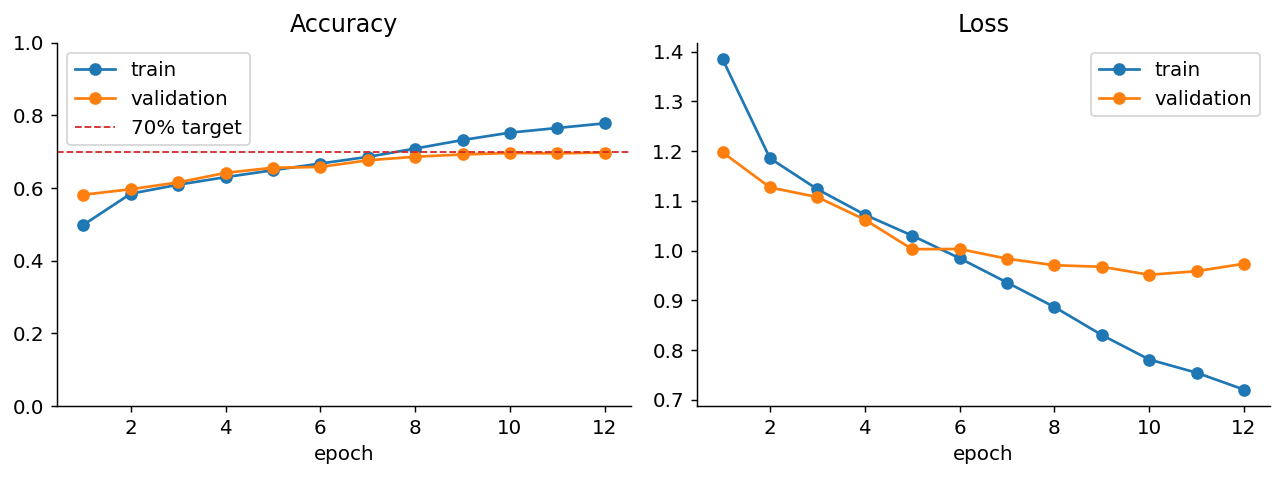

In [24]:
history = metadata.get("history", [])
if history:
    epochs = [row["epoch"] for row in history]
    train_acc = [row["train_acc"] for row in history]
    val_acc = [row["val_acc"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row["val_loss"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(epochs, train_acc, marker="o", label="train")
    axes[0].plot(epochs, val_acc, marker="o", label="validation")
    axes[0].axhline(0.70, color="tab:red", linestyle="--", linewidth=1, label="70% target")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    axes[1].plot(epochs, train_loss, marker="o", label="train")
    axes[1].plot(epochs, val_loss, marker="o", label="validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "training_history.png", bbox_inches="tight")
    plt.show()
else:
    print("No history stored in checkpoint metadata.")

## Final Test Evaluation

The next cell computes predictions, confidences, and class probabilities on the FER-2013 test set. For the final blog figures, `MAX_SAMPLES` should stay set to `None` so that the full test split is used.

This is the held-out result we report after selecting the model on validation data.

In [25]:
MAX_SAMPLES = None

def collect_predictions(model, dataset, device, max_samples=None):
    model.eval()
    total = len(dataset) if max_samples is None else min(len(dataset), max_samples)
    y_true, y_pred, confidences, probabilities = [], [], [], []

    with torch.no_grad():
        for idx in range(total):
            image, label = dataset[idx]
            logits = model(image.unsqueeze(0).to(device))
            probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
            pred = int(np.argmax(probs))
            y_true.append(label)
            y_pred.append(pred)
            confidences.append(float(probs[pred]))
            probabilities.append(probs)

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(confidences),
        np.vstack(probabilities),
    )

y_true, y_pred, confidences, probabilities = collect_predictions(model, test_dataset, device, MAX_SAMPLES)
overall_accuracy = float((y_true == y_pred).mean())
overall_accuracy

0.6855670103092784

## Figures 3 and 4: Confusion Matrix and Per-Class Accuracy

Overall accuracy is not enough for this project. A model that performs well on `happy` and `surprise` but poorly on `fear` or `sad` would be risky in an assistive interface.

The confusion matrix and per-class accuracy plot show which expression labels the model handles relatively well and which ones should be treated more cautiously.

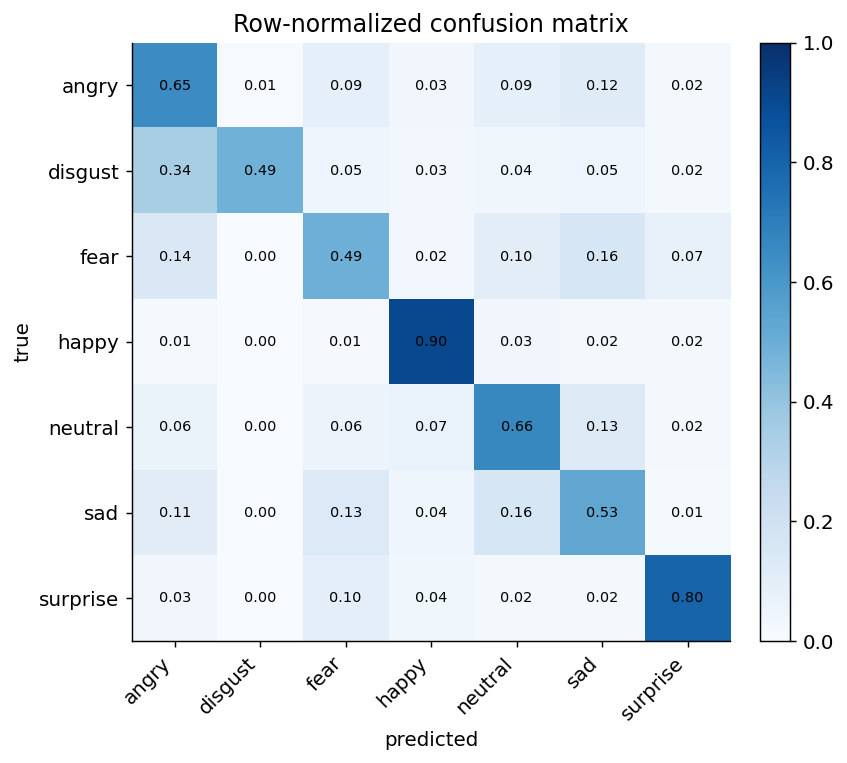

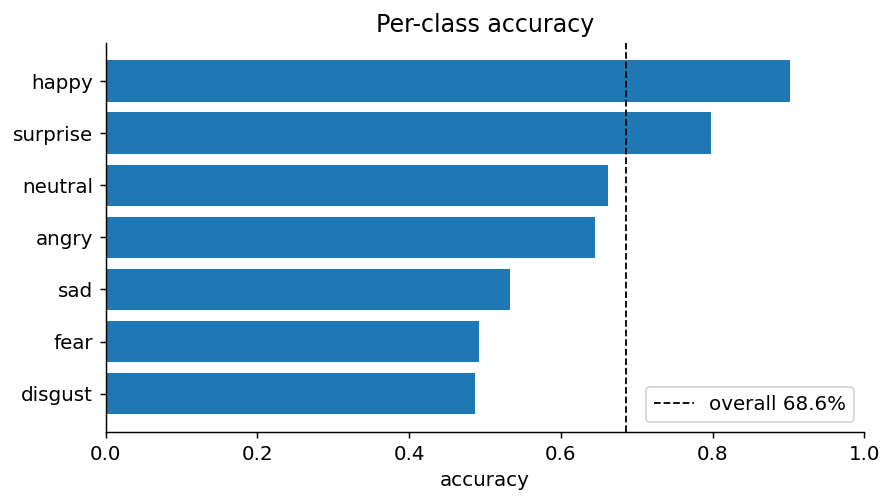

In [26]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names)), class_names)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Row-normalized confusion matrix")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrix_normalized.png", bbox_inches="tight")
plt.show()

per_class_acc = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
order = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(np.array(class_names)[order], per_class_acc[order], color="tab:blue")
ax.axvline(overall_accuracy, color="black", linestyle="--", linewidth=1, label=f"overall {overall_accuracy:.1%}")
ax.set_xlim(0, 1)
ax.set_xlabel("accuracy")
ax.set_title("Per-class accuracy")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "per_class_accuracy.png", bbox_inches="tight")
plt.show()

## Figure 5: Confidence Threshold Tradeoff

A live interface does not have to label every frame. One possible safety mechanism is to show a prediction only when the model's confidence is above a threshold.

This plot shows the tradeoff: as the threshold rises, the system labels fewer frames, but the labels it does show should be more reliable. This is one way to connect model evaluation to interface design.

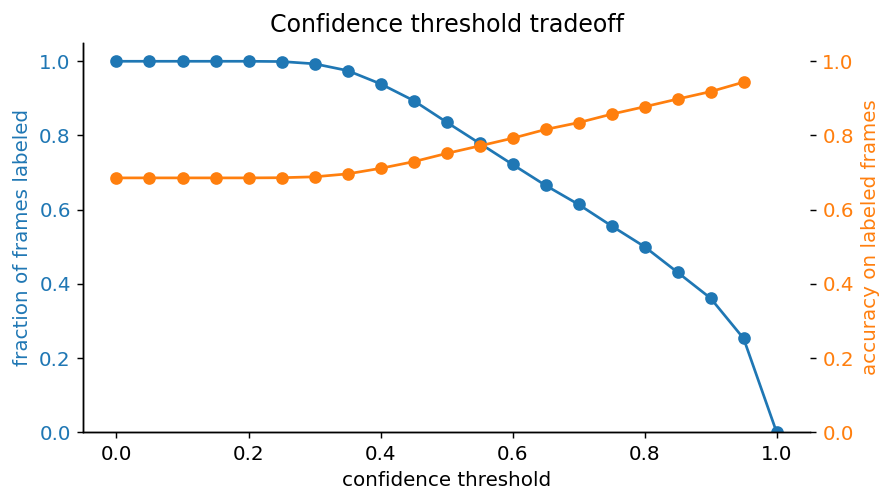

In [27]:
thresholds = np.linspace(0.0, 1.0, 21)
coverage = []
threshold_accuracy = []

correct = y_true == y_pred
for threshold in thresholds:
    keep = confidences >= threshold
    coverage.append(float(keep.mean()))
    threshold_accuracy.append(float(correct[keep].mean()) if keep.any() else np.nan)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(thresholds, coverage, marker="o", color="tab:blue", label="coverage")
ax1.set_xlabel("confidence threshold")
ax1.set_ylabel("fraction of frames labeled", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(thresholds, threshold_accuracy, marker="o", color="tab:orange", label="accuracy above threshold")
ax2.set_ylabel("accuracy on labeled frames", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0, 1.05)

ax1.set_title("Confidence threshold tradeoff")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confidence_threshold_tradeoff.png", bbox_inches="tight")
plt.show()

## Figure 6: Reliability Diagram

This reliability diagram checks whether the model's confidence scores line up with empirical accuracy. If the model were perfectly calibrated, predictions made with about 80% confidence would be correct about 80% of the time.

For our project, this matters because an assistive tool should communicate uncertainty honestly. Even a reasonably accurate model can be misleading if its confidence scores are badly calibrated.

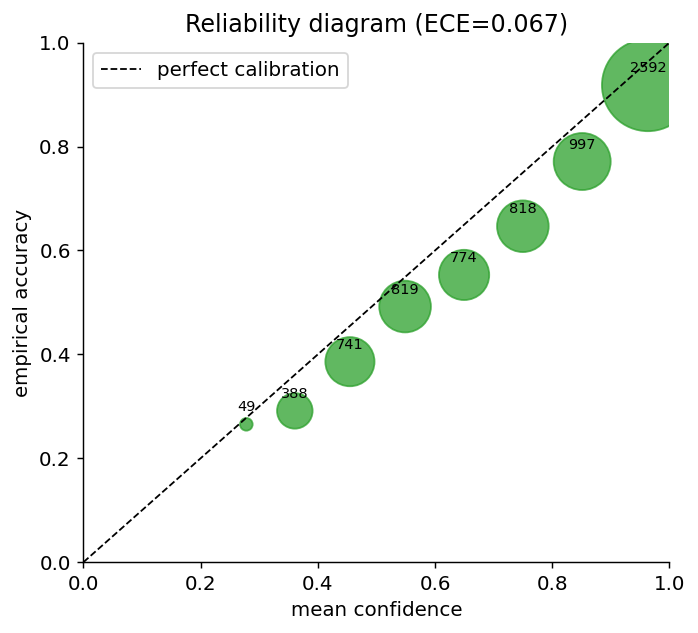

0.06705010469974867

In [28]:
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(confidences, bins, right=True) - 1
bin_ids = np.clip(bin_ids, 0, len(bins) - 2)

bin_centers, bin_acc, bin_conf, bin_counts = [], [], [], []
ece = 0.0
for b in range(len(bins) - 1):
    mask = bin_ids == b
    if not mask.any():
        continue
    acc = float(correct[mask].mean())
    conf = float(confidences[mask].mean())
    count = int(mask.sum())
    bin_centers.append((bins[b] + bins[b + 1]) / 2)
    bin_acc.append(acc)
    bin_conf.append(conf)
    bin_counts.append(count)
    ece += (count / len(confidences)) * abs(acc - conf)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="perfect calibration")
ax.scatter(bin_conf, bin_acc, s=np.maximum(np.array(bin_counts), 10), alpha=0.75, color="tab:green")
for x, y, count in zip(bin_conf, bin_acc, bin_counts):
    ax.text(x, y + 0.025, str(count), ha="center", fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("mean confidence")
ax.set_ylabel("empirical accuracy")
ax.set_title(f"Reliability diagram (ECE={ece:.3f})")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "reliability_diagram.png", bbox_inches="tight")
plt.show()

ece

## Notes for Rerunning

For the final blog figures, use the saved clean checkpoint selected above. The optional training blocks are included so that our experimental process is visible, but they are not necessary for simply regenerating the figures.

A typical local rerun is:

1. Install the packages in `requirements.txt`.
2. Make sure the model files are present in `models/`.
3. Run the dataset, checkpoint selection, evaluation, and figure cells.
4. Confirm that the generated images appear in `assets/figures/`.